In [1]:
from gen_catalyst_design.discrete_space_diffusion import ExponentialScheduler, CosineScheduler, LinearScheduler
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams["font.size"] = 14
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 12

/opt/anaconda3/envs/cat_opt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


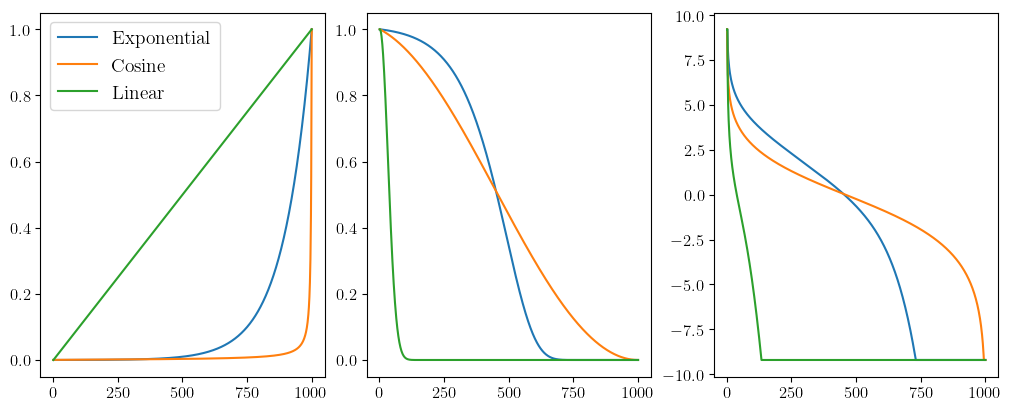

In [8]:
fig, axs = plt.subplots(1,3, figsize=(10,4), layout="constrained")
schedules = {
    "Exponential":ExponentialScheduler, 
    "Cosine":CosineScheduler, 
    "Linear":LinearScheduler
}
beta_max = 1.0
beta_min = 1e-4
timesteps = torch.arange(1, 1001, 1)
for schedule_type in schedules:
    if schedule_type == "Cosine":
        scheduler = schedules[schedule_type](beta_min=beta_min, beta_max=beta_max, reg=0.1)
    else:
        scheduler = schedules[schedule_type](beta_min=beta_min, beta_max=beta_max)
    betas = scheduler(timesteps).numpy()
    alphas = 1.0-betas
    alpha_accum = np.array([np.prod(alphas[:i]) for i, _ in enumerate(alphas)])
    alpha_accum = alpha_accum.clip(min=1e-4, max=1.0-1e-4)
    snr_t = alpha_accum/(1.0-alpha_accum)
    axs[0].plot(timesteps.numpy(), betas, label=schedule_type)
    axs[1].plot(timesteps.numpy(), alpha_accum, label=schedule_type)
    axs[2].plot(timesteps.numpy(), np.log(snr_t))
    axs[0].legend()
